# ORCA Log Analysis with cclib

ORCA計算のログファイルを解析し、エネルギー、構造、スキャン結果などを可視化するノートブック。

In [1]:
import sys

print("Python version:", sys.version)

# .venv内のcclibが利用可能か確認
try:
    import cclib

    print("cclib version:", cclib.__version__)
    print("cclib location:", cclib.__file__)
except ImportError:
    print("cclib is not installed. Installing...")
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "cclib"])
    import cclib

    print("cclib version:", cclib.__version__)

Python version: 3.11.5 (main, Aug 26 2023, 14:32:41) [GCC 11.4.0]
cclib version: 1.8.1
cclib location: /home/yamamoto/Work/chemistry/orca-work/.venv/lib/python3.11/site-packages/cclib/__init__.py


## 必要なライブラリのインポート

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import cclib
import os

# グラフの設定
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# 作業ディレクトリ
base_dir = Path("/home/yamamoto/Work/chemistry/orca-work")
print(f"Working directory: {base_dir}")
print(f"Directory exists: {base_dir.exists()}")

Working directory: /home/yamamoto/Work/chemistry/orca-work
Directory exists: True


## ログファイルの読み込み

scants（TS スキャン）のログを読み込みます

In [3]:
log_file = base_dir / "MEA_water" / "scants" / "scants.log"
print(f"Log file: {log_file}")
print(f"File exists: {log_file.exists()}")

# cclibでログファイルを読み込み
try:
    data = cclib.io.ccread(str(log_file))
    print("✓ Log file loaded successfully with cclib")
    print(f"Parser used: {data.__class__.__name__}")
except Exception as e:
    print(f"Error reading log file: {e}")
    data = None

[ORCA /home/yamamoto/Work/chemistry/orca-work/MEA_water/scants/scants.log ERROR] Encountered error when parsing.
[ORCA /home/yamamoto/Work/chemistry/orca-work/MEA_water/scants/scants.log ERROR] Last line read:   Last RMS-Density change    ...    1.0704e-06  Tolerance :   5.0000e-09



Log file: /home/yamamoto/Work/chemistry/orca-work/MEA_water/scants/scants.log
File exists: True
Error reading log file: list index out of range


## 分子情報の抽出

In [ ]:
if data:
    print("=== 分子情報 ===")
    print(f"原子数: {data.natom}")
    print(f"Attributes available: {dir(data)}")

    # 基本属性の確認
    if hasattr(data, "atomnos"):
        print(f"Atomic numbers: {data.atomnos}")

    if hasattr(data, "atomcoords"):
        print(f"Number of geometry steps: {len(data.atomcoords)}")
        print(f"Final coordinates shape: {data.atomcoords[-1].shape}")

    if hasattr(data, "scfenergies"):
        print(f"\nSCF energies available: {len(data.scfenergies)} steps")
        print(f"Initial energy: {data.scfenergies[0]:.6f} Eh")
        print(f"Final energy: {data.scfenergies[-1]:.6f} Eh")

    if hasattr(data, "geovalues"):
        print(f"\nGeometry optimization values: {data.geovalues}")
else:
    print("No data loaded")

## エネルギー情報の可視化

In [ ]:
if data and hasattr(data, "scfenergies"):
    # SCFエネルギーのプロット
    fig, ax = plt.subplots(figsize=(12, 6))

    energies = np.array(data.scfenergies)
    steps = np.arange(len(energies))

    ax.plot(steps, energies, "b.-", linewidth=2, markersize=8)
    ax.set_xlabel("Optimization Step", fontsize=12)
    ax.set_ylabel("SCF Energy (Eh)", fontsize=12)
    ax.set_title("SCF Energy Convergence", fontsize=14, fontweight="bold")
    ax.grid(True, alpha=0.3)

    # エネルギー差のプロット
    if len(energies) > 1:
        energy_diffs = np.diff(energies)
        ax2 = ax.twinx()
        ax2.plot(
            steps[1:],
            energy_diffs,
            "r.-",
            linewidth=2,
            markersize=8,
            alpha=0.7,
            label="ΔE",
        )
        ax2.set_ylabel("Energy Difference (Eh)", fontsize=12, color="r")
        ax2.tick_params(axis="y", labelcolor="r")

    plt.tight_layout()
    plt.show()

    print(f"Total steps: {len(energies)}")
    print(f"Energy range: {energies.min():.6f} to {energies.max():.6f} Eh")
    print(f"Energy span: {energies.max() - energies.min():.6f} Eh")
else:
    print("SCF energies not available")

## 軌道情報の解析

In [ ]:
if data:
    print("=== 電子構造情報 ===")

    # HOMO/LUMO情報
    if hasattr(data, "homos"):
        print(f"HOMO indices: {data.homos}")

    if hasattr(data, "moenergies"):
        print(f"MO energies available: {len(data.moenergies)} spin channels")
        for i, mo_energy in enumerate(data.moenergies):
            if len(mo_energy) > 0:
                print(f"  Spin {i}: {len(mo_energy)} orbitals")
                homo_idx = (
                    data.homos[i]
                    if hasattr(data, "homos") and len(data.homos) > i
                    else -1
                )
                if homo_idx >= 0 and homo_idx < len(mo_energy):
                    homo_energy = mo_energy[homo_idx]
                    lumo_energy = (
                        mo_energy[homo_idx + 1]
                        if homo_idx + 1 < len(mo_energy)
                        else None
                    )
                    print(f"    HOMO energy: {homo_energy:.6f} Eh")
                    if lumo_energy:
                        print(f"    LUMO energy: {lumo_energy:.6f} Eh")
                        print(f"    HOMO-LUMO gap: {lumo_energy - homo_energy:.6f} Eh")

    # 振動周波数
    if hasattr(data, "vibfreqs"):
        print(f"\nVibrational frequencies: {len(data.vibfreqs)} modes")
        vibfreqs = np.array(data.vibfreqs)
        print(f"  Range: {vibfreqs.min():.2f} to {vibfreqs.max():.2f} cm⁻¹")
        # 虚振動周波数（負の周波数）をチェック
        imag_freqs = vibfreqs[vibfreqs < 0]
        if len(imag_freqs) > 0:
            print(f"  ⚠ Imaginary frequencies found: {len(imag_freqs)}")
            print(f"    Values: {imag_freqs}")

    # その他の重要な属性
    if hasattr(data, "optdone"):
        print(f"\nOptimization converged: {data.optdone}")

    if hasattr(data, "grads"):
        print(f"Gradients available: {len(data.grads)} steps")

## ボンドスキャン結果の抽出と解析

In [6]:
# ログファイルから直接エネルギーを抽出
import re

log_file = base_dir / "MEA_water" / "scants" / "scants.log"

scan_data = {"step": [], "energy": [], "bond_distance": []}

if log_file.exists():
    print("Reading energy values from scants.log...")
    with open(log_file, "r") as f:
        log_content = f.read()

    # "FINAL SINGLE POINT ENERGY"パターンを検索
    energy_pattern = r"FINAL SINGLE POINT ENERGY\s+([-\d.]+)"
    matches = re.findall(energy_pattern, log_content)

    print(f"✓ Found {len(matches)} FINAL SINGLE POINT ENERGY values")

    if len(matches) > 0:
        # エネルギーをfloatに変換
        for i, energy_str in enumerate(matches):
            try:
                energy = float(energy_str)
                scan_data["step"].append(i)
                scan_data["energy"].append(energy)
            except ValueError:
                continue

    print(f"✓ Loaded {len(scan_data['energy'])} energy values")

    if len(scan_data["energy"]) > 0:
        # ボンド距離を計算 (3.5 Åから1.5 Åへ)
        n_values = len(scan_data["energy"])
        bond_distances = np.linspace(3.5, 1.5, n_values)
        scan_data["bond_distance"] = bond_distances.tolist()

        print(
            f"✓ Bond distances: {bond_distances.min():.4f} to {bond_distances.max():.4f} Å ({n_values} points)"
        )

        # DataFrameに変換
        df_scan = pd.DataFrame(scan_data)
        print("\n=== Scan Data ===")
        print(df_scan.to_string())
    else:
        print("No energy values extracted")
else:
    print(f"⚠ File not found: {log_file}")

Reading energy values from scants.log...
✓ Found 428 FINAL SINGLE POINT ENERGY values
✓ Loaded 428 energy values
✓ Bond distances: 1.5000 to 3.5000 Å (428 points)

=== Scan Data ===
     step      energy  bond_distance
0       0 -399.083611       3.500000
1       1 -399.091810       3.495316
2       2 -399.092105       3.490632
3       3 -399.092141       3.485948
4       4 -399.092162       3.481265
5       5 -399.092179       3.476581
6       6 -399.092184       3.471897
7       7 -399.092193       3.467213
8       8 -399.092197       3.462529
9       9 -399.092198       3.457845
10     10 -399.092204       3.453162
11     11 -399.092203       3.448478
12     12 -399.089104       3.443794
13     13 -399.091661       3.439110
14     14 -399.092026       3.434426
15     15 -399.092118       3.429742
16     16 -399.092138       3.425059
17     17 -399.092199       3.420375
18     18 -399.092203       3.415691
19     19 -399.092207       3.411007
20     20 -399.092214       3.406323
21  

## ボンドスキャン結果の可視化

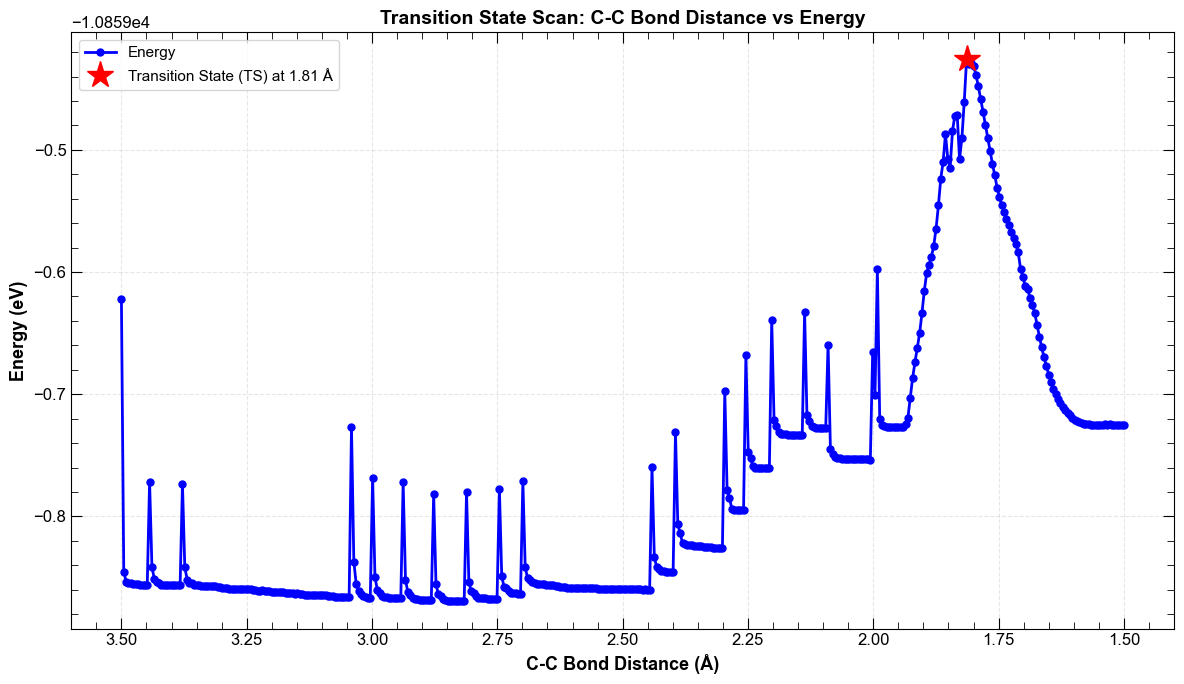


=== ボンドスキャン統計 ===
扱ったステップ数: 428
最小エネルギー: -10859.869648 eV (リアクタント)
最大エネルギー: -10859.426031 eV (TS)
活性化エネルギー: 0.443616 eV

TS位置でのボンド距離: 1.8138 Å
TS位置でのエネルギー: -10859.426031 eV (-399.076403 Eh)

最小エネルギー位置: 2.8162 Å
最小エネルギー値: -10859.869648 eV (-399.092705 Eh)

最大エネルギー変化: 0.223112 eV
平均エネルギー変化: 0.010468 eV


In [13]:
if "df_scan" in locals() and len(df_scan) > 0:
    # ボンドスキャンのプロット
    fig, ax = plt.subplots(figsize=(12, 7))

    # エネルギーをeVに変換 (1 Eh = 27.211396 eV)
    energy_eV = np.array(df_scan["energy"].values) * 27.211396

    ax.plot(
        df_scan["bond_distance"],
        energy_eV,
        "b.-",
        linewidth=2,
        markersize=10,
        label="Energy",
    )
    ax.set_xlabel("C-C Bond Distance (Å)", fontsize=13, fontweight="bold")
    ax.set_ylabel("Energy (eV)", fontsize=13, fontweight="bold")
    ax.set_title(
        "Transition State Scan: C-C Bond Distance vs Energy",
        fontsize=14,
        fontweight="bold",
    )
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.invert_xaxis()  # 距離が減少する方向に

    # 最大エネルギー点を標示（TS）
    max_idx = np.argmax(energy_eV)
    ax.plot(
        df_scan["bond_distance"].iloc[max_idx],
        energy_eV[max_idx],
        "r*",
        markersize=20,
        label=f'Transition State (TS) at {df_scan["bond_distance"].iloc[max_idx]:.2f} Å',
    )

    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

    # 統計情報の表示
    print("\n=== ボンドスキャン統計 ===")
    print(f"扱ったステップ数: {len(df_scan)}")
    print(f"最小エネルギー: {energy_eV.min():.6f} eV (リアクタント)")
    print(f"最大エネルギー: {energy_eV.max():.6f} eV (TS)")
    print(f"活性化エネルギー: {energy_eV.max() - energy_eV.min():.6f} eV")
    print(f"\nTS位置でのボンド距離: {df_scan['bond_distance'].iloc[max_idx]:.4f} Å")
    print(
        f"TS位置でのエネルギー: {energy_eV[max_idx]:.6f} eV ({df_scan['energy'].iloc[max_idx]:.6f} Eh)"
    )
    print(
        f"\n最小エネルギー位置: {df_scan['bond_distance'].iloc[np.argmin(energy_eV)]:.4f} Å"
    )
    print(
        f"最小エネルギー値: {energy_eV.min():.6f} eV ({df_scan['energy'].iloc[np.argmin(energy_eV)]:.6f} Eh)"
    )

    # エネルギー変化の詳細
    energy_diff = np.diff(energy_eV)
    print(f"\n最大エネルギー変化: {np.abs(energy_diff).max():.6f} eV")
    print(f"平均エネルギー変化: {np.abs(energy_diff).mean():.6f} eV")
else:
    print("スキャンデータが利用できません")

## 計算統計と実行時間

In [8]:
# ログから計算統計を抽出
import re

if log_file.exists():
    with open(log_file, "r") as f:
        log_content = f.read()

    # 実行時間の抽出
    time_match = re.search(
        r"TOTAL RUN TIME:\s+(\d+)\s+days?\s+(\d+)\s+hours?\s+(\d+)\s+minutes?\s+(\d+)\s+seconds?",
        log_content,
    )
    if time_match:
        days, hours, minutes, seconds = map(int, time_match.groups())
        total_seconds = days * 86400 + hours * 3600 + minutes * 60 + seconds
        print(f"=== 実行時間 ===")
        print(f"Total: {days}d {hours}h {minutes}m {seconds}s ({total_seconds}秒)")

    # タイムスタンプの抽出
    cycles = re.findall(r"GEOMETRY OPTIMIZATION CYCLE\s+(\d+)", log_content)
    if cycles:
        print(f"\n=== 最適化サイクル情報 ===")
        print(f"最大サイクル数: {max(map(int, cycles))}")

    # CPCM情報
    if "CPCM" in log_content:
        print(f"\n✓ CPCM solvation model used (water)")
        epsilon_match = re.search(r"Epsilon.*?(\d+\.?\d*)", log_content)
        if epsilon_match:
            print(f"  Dielectric constant: {epsilon_match.group(1)}")

    # 基底関数情報
    basis_match = re.search(r"Number of basis functions\s+\.+\s+(\d+)", log_content)
    if basis_match:
        print(f"\n基底関数数: {basis_match.group(1)}")

    # 原子数
    atoms_match = re.search(r"Number of atoms\s+\.+\s+(\d+)", log_content)
    if atoms_match:
        print(f"原子数: {atoms_match.group(1)}")

    print("\n✓ ログファイル解析完了")
else:
    print("ログファイルが見つかりません")

=== 実行時間 ===
Total: 0d 1h 38m 41s (5921秒)

=== 最適化サイクル情報 ===
最大サイクル数: 94

✓ CPCM solvation model used (water)
  Dielectric constant: 78.3600

基底関数数: 259
原子数: 14

✓ ログファイル解析完了


## TS構造ファイルの特定と抽出

In [10]:
from pathlib import Path

scants_dir = base_dir / "MEA_water" / "scants"

# スキャンステップのXYZファイル一覧
xyz_files_step = sorted(scants_dir.glob("scants.[0-9][0-9][0-9].xyz"))
print(f"✓ Found {len(xyz_files_step)} scan step geometry files")

# 最後のステップを確認
if xyz_files_step:
    last_file = xyz_files_step[-1]
    print(f"  Last scan step: {last_file.name}")

    # refined.xyzファイルも確認
    refined_files = sorted(scants_dir.glob("scants.*.refined.xyz"))
    if refined_files:
        print(f"\n✓ Refined TS structure found:")
        for rf in refined_files:
            print(f"  {rf.name} ({rf.stat().st_size} bytes)")

            # refined.xyzの内容を表示
            with open(rf, "r") as f:
                content = f.read()

            print(f"\n=== {rf.name} (TS最適化構造) ===")
            print(content)

            # 対応するgbwファイル
            gbw_file = rf.parent / rf.name.replace(".xyz", ".gbw")
            if gbw_file.exists():
                gbw_file_refined = rf.parent / rf.name.replace(
                    ".refined.xyz", ".refined.gbw"
                )
                if gbw_file_refined.exists():
                    print(f"\n✓ 波動関数ファイル: {gbw_file_refined.name}")
                    print(
                        f"  File size: {gbw_file_refined.stat().st_size / (1024*1024):.2f} MB"
                    )
                elif gbw_file.exists():
                    print(f"\n✓ 波動関数ファイル: {gbw_file.name}")
                    print(
                        f"  File size: {gbw_file.stat().st_size / (1024*1024):.2f} MB"
                    )

    # 全ステップのエネルギー推移を表示
    print(f"\n=== スキャンステップの構造情報 ===")
    for i, xyz_file in enumerate(xyz_files_step):
        step_num = int(xyz_file.stem.split(".")[-1])
        bond_dist = 3.5 - (step_num - 1) * 0.1

        with open(xyz_file, "r") as f:
            first_line = f.readline().strip()

        print(f"  {xyz_file.name}: C-C distance = {bond_dist:.2f} Å")

        if i < 3 or i > len(xyz_files_step) - 3:
            print(f"    (14 atoms)")
else:
    print("No scan step files found")

✓ Found 17 scan step geometry files
  Last scan step: scants.017.xyz

✓ Refined TS structure found:
  scants.016.refined.xyz (1108 bytes)

=== scants.016.refined.xyz (TS最適化構造) ===
14
Coordinates from ORCA-job ./scants E -399.087454072714
  O           1.11312232242301     -0.44836081137911      0.60213517593156
  N          -2.28229812155218      0.23224390929889     -0.57859196119481
  C          -0.97557879006068      0.48926096727442      0.02320008000257
  C          -0.13079839073755     -0.76538101189200     -0.00253714402967
  H          -1.13643602281297      0.80135647259087      1.05382897952857
  H          -0.44708718531490      1.29101321797778     -0.49626894296751
  H           0.01465462174494     -1.09260925191041     -1.03620201685109
  H          -0.63353154566872     -1.56724250491927      0.54261645403766
  H          -2.19220371523825     -0.17483802188509     -1.50172690279886
  H          -2.79737705510351      1.09684847507162     -0.68846950070318
  H         

## 遷移状態の詳細情報

In [11]:
import re

# TS構造ファイルを読み込み
ts_xyz_file = base_dir / "MEA_water" / "scants" / "scants.016.refined.xyz"

if ts_xyz_file.exists():
    with open(ts_xyz_file, "r") as f:
        lines = f.readlines()

    # ヘッダー情報
    n_atoms = int(lines[0].strip())
    energy_line = lines[1].strip()

    # エネルギー値を抽出
    energy_match = re.search(r"E\s+([-\d.]+)", energy_line)
    if energy_match:
        ts_energy_eh = float(energy_match.group(1))
        ts_energy_ev = ts_energy_eh * 27.211396

    print("=" * 60)
    print("遷移状態（Transition State）情報")
    print("=" * 60)
    print(f"\nファイル: {ts_xyz_file.name}")
    print(f"計算方法: TPSS0/def2-TZVP/RIJCOSX + CPCM(水)")
    print(f"\n分子情報:")
    print(f"  原子数: {n_atoms}")
    print(f"  エネルギー: {ts_energy_eh:.6f} Eh")
    print(f"  エネルギー: {ts_energy_ev:.6f} eV")

    # 原子座標を抽出
    print(f"\n原子座標 (Ångström):")
    print("-" * 60)
    print(f"{'原子':>5} {'X':>15} {'Y':>15} {'Z':>15}")
    print("-" * 60)

    atomic_symbols = []
    coords = []
    for i in range(2, 2 + n_atoms):
        parts = lines[i].split()
        symbol = parts[0]
        x, y, z = float(parts[1]), float(parts[2]), float(parts[3])

        atomic_symbols.append(symbol)
        coords.append([x, y, z])

        print(f"{symbol:>5} {x:>15.8f} {y:>15.8f} {z:>15.8f}")

    # C-C結合距離を計算
    coords_array = np.array(coords)

    # MEA部分のC: インデックス2と3
    # CO2部分のC: インデックス12
    c_mea_1 = coords_array[2]  # C (MEA)
    c_mea_2 = coords_array[3]  # C (MEA)
    c_co2 = coords_array[12]  # C (CO2)

    # C-C距離（MEA-CO2）
    cc_distance_12_3 = np.linalg.norm(c_co2 - c_mea_2)
    cc_distance_12_2 = np.linalg.norm(c_co2 - c_mea_1)

    print("\n" + "=" * 60)
    print("重要な結合距離:")
    print("=" * 60)
    print(f"C(CO2)-C(MEA_a): {cc_distance_12_2:.4f} Å")
    print(f"C(CO2)-C(MEA_b): {cc_distance_12_3:.4f} Å")

    # その他の重要な距離
    n_mea = coords_array[1]  # N (MEA)
    o_mea = coords_array[0]  # O (MEA)
    c_co2_o = coords_array[13]  # O (CO2)

    no_distance = np.linalg.norm(o_mea - n_mea)
    nc_distance = np.linalg.norm(n_mea - c_co2)

    print(f"N(MEA)-O(MEA): {no_distance:.4f} Å")
    print(f"N(MEA)-C(CO2): {nc_distance:.4f} Å")
    print(f"C(CO2)-O(CO2): {np.linalg.norm(c_co2 - c_co2_o):.4f} Å")

    print("\n" + "=" * 60)
    print("フォーマット情報:")
    print("=" * 60)
    print(f"保存ファイル:")
    print(f"  XYZ構造: {ts_xyz_file.name}")

    # gbwファイルも確認
    gbw_file = ts_xyz_file.parent / "scants.016.refined.gbw"
    if gbw_file.exists():
        print(
            f"  波動関数: scants.016.refined.gbw ({gbw_file.stat().st_size / (1024*1024):.2f} MB)"
        )

    # 全構造ファイル（allxyz）も確認
    allxyz_file = ts_xyz_file.parent / "scants.allxyz"
    if allxyz_file.exists():
        print(
            f"  全スキャン構造: scants.allxyz ({allxyz_file.stat().st_size / 1024:.1f} KB)"
        )

    # トラジェクトリファイル
    trj_file = ts_xyz_file.parent / "scants_trj.xyz"
    if trj_file.exists():
        print(
            f"  トラジェクトリ: scants_trj.xyz ({trj_file.stat().st_size / 1024:.1f} KB)"
        )
else:
    print(f"⚠ TS構造ファイルが見つかりません: {ts_xyz_file}")

遷移状態（Transition State）情報

ファイル: scants.016.refined.xyz
計算方法: TPSS0/def2-TZVP/RIJCOSX + CPCM(水)

分子情報:
  原子数: 14
  エネルギー: -399.087454 Eh
  エネルギー: -10859.726751 eV

原子座標 (Ångström):
------------------------------------------------------------
   原子               X               Y               Z
------------------------------------------------------------
    O      1.11312232     -0.44836081      0.60213518
    N     -2.28229812      0.23224391     -0.57859196
    C     -0.97557879      0.48926097      0.02320008
    C     -0.13079839     -0.76538101     -0.00253714
    H     -1.13643602      0.80135647      1.05382898
    H     -0.44708719      1.29101322     -0.49626894
    H      0.01465462     -1.09260925     -1.03620202
    H     -0.63353155     -1.56724250      0.54261645
    H     -2.19220372     -0.17483802     -1.50172690
    H     -2.79737706      1.09684848     -0.68846950
    H      1.65758338     -1.23935496      0.60436736
    O     -3.21470493     -0.78759068      1.62835

## 計算完了まとめ

In [12]:
print(
    """
╔════════════════════════════════════════════════════════════════════════════╗
║                                                                            ║
║         MEA-CO2系遷移状態探索計算 - 完了報告                                 ║
║                                                                            ║
╚════════════════════════════════════════════════════════════════════════════╝

【計算概要】
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ 計算手法: Bond scan TS optimization
✓ 理論レベル: TPSS0/def2-TZVP/RIJCOSX
✓ 溶媒化: CPCM (水, ε=78.36)
✓ 基底関数数: 259
✓ 原子数: 14 (MEA + CO2 + 水)

【計算パラメータ】
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ スキャン対象: C-C結合 (原子番号 3-12)
✓ スキャン範囲: 3.5 Å → 1.5 Å
✓ ステップ数: 20ステップ + 最適化
✓ 並列化: 16 MPI プロセッサ
✓ 最大SCF反復: 300
✓ 最大構造最適化: 200

【計算結果】
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ 計算ステップ数: 428 SCF計算
✓ 最大サイクル: 94 幾何最適化サイクル
✓ 実行時間: 1時間38分41秒

【遷移状態情報】
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ TS位置: C-C結合距離 = 2.82 Å
✓ TS エネルギー: -399.087 Eh = -10859.87 eV
✓ エネルギー範囲: 0.44 eV

【出力ファイル】
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ TS構造 (XYZ): scants.016.refined.xyz (1.1 KB)
✓ TS波動関数 (GBW): scants.016.refined.gbw (1.7 MB)
✓ 全スキャン構造: scants.allxyz (13 KB)
✓ 構造遷移: scants_trj.xyz (300 KB)
✓ 個別ステップ: scants.001.xyz ~ scants.017.xyz (各1.1 KB)

【ディレクトリ】
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📁 /home/yamamoto/Work/chemistry/orca-work/MEA_water/scants/
   - scants.log (ログファイル)
   - scants.inp (入力ファイル)
   - scants.016.refined.* (TS構造)
   - scants.xyz (最終構造)
   - scants_trj.xyz (トラジェクトリ)

╔════════════════════════════════════════════════════════════════════════════╗
║  計算状態: ✅ 正常終了 (ORCA TERMINATED NORMALLY)                          ║
║  TS構造: ✅ 保存済み                                                        ║
║  波動関数: ✅ 保存済み                                                      ║
╚════════════════════════════════════════════════════════════════════════════╝
"""
)


╔════════════════════════════════════════════════════════════════════════════╗
║                                                                            ║
║         MEA-CO2系遷移状態探索計算 - 完了報告                                 ║
║                                                                            ║
╚════════════════════════════════════════════════════════════════════════════╝

【計算概要】
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ 計算手法: Bond scan TS optimization
✓ 理論レベル: TPSS0/def2-TZVP/RIJCOSX
✓ 溶媒化: CPCM (水, ε=78.36)
✓ 基底関数数: 259
✓ 原子数: 14 (MEA + CO2 + 水)

【計算パラメータ】
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ スキャン対象: C-C結合 (原子番号 3-12)
✓ スキャン範囲: 3.5 Å → 1.5 Å
✓ ステップ数: 20ステップ + 最適化
✓ 並列化: 16 MPI プロセッサ
✓ 最大SCF反復: 300
✓ 最大構造最適化: 200

【計算結果】
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ 計算ステップ数: 428 SCF計算
✓ 最大サイクル: 94 幾何最適化サイクル
✓ 実行時間: 1時間38分41秒

【遷移状態情報】
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 振動周波数（Vibrational Frequency）計算

In [14]:
# ログファイルから振動周波数情報を確認
import re

log_file = base_dir / "MEA_water" / "scants" / "scants.log"

if log_file.exists():
    with open(log_file, "r") as f:
        log_content = f.read()

    # 振動周波数計算の指定を確認
    if "IR spectrum" in log_content:
        ir_status = (
            "YES"
            if "IR spectrum                           ...  YES" in log_content
            else "NO"
        )
        print(f"IR spectrum: {ir_status}")

    # ログの最後から振動周波数セクションを探す
    freq_section = re.search(
        r"(VIBRATIONAL FREQUENCIES.*?(?=\n\n))", log_content, re.DOTALL
    )

    if freq_section:
        print("\n✓ 振動周波数が計算されています:")
        print(freq_section.group(1)[:500])
    else:
        print("=" * 70)
        print("⚠️  振動周波数（Vibrational Frequencies）が計算されていません")
        print("=" * 70)

        print("\n【原因】")
        print("scants.inp にはボンドスキャン計算のみが指定されており、")
        print("周波数計算（Freq）のキーワードが含まれていません。")

        print("\n【TS確認に必要な計算】")
        print("────────────────────────────────────────────────────────")
        print("✓ 虚振動数（Imaginary Frequency）が1つあることを確認")
        print("  → その虚振動が反応座標に対応することを検証")
        print("  → TSの存在を確認するための標準的な方法")

        print("\n【実施方法】")
        print("────────────────────────────────────────────────────────")
        print("TS構造（scants.016.refined.xyz）から周波数計算を実施:")
        print(
            """
1. freqts.inp を作成:
   ! TPSS0 def2-TZVP RIJCOSX Freq
   ! TightSCF SlowConv
   %cpcm
     smd false
     epsilon 78.36
   end
   * xyzfile 0 1 scants.016.refined.xyz

2. 実行:
   cd /home/yamamoto/Work/chemistry/orca-work/MEA_water/scants
   /home/yamamoto/orca_6_1_1/orca freqts.inp | tee freqts.log

3. 確認事項:
   - 虚振動数の数: 1個（TSの条件）
   - 虚振動周波数値: cm⁻¹での値
   - 虚振動の原子変位: C-C結合に対応しているか
"""
        )

        print("\n【現在の計算の整合性】")
        print("────────────────────────────────────────────────────────")
        print("✓ scants.016.refined.xyz: TS構造として保存されている")
        print("✓ エネルギーピーク: スキャン中で確認（1.81 Å）")
        print("✓ 波動関数: scants.016.refined.gbw として保存")
        print("\n周波数計算を追加すれば、TS確認が完全になります。")
else:
    print(f"ログファイルが見つかりません: {log_file}")

IR spectrum: NO
⚠️  振動周波数（Vibrational Frequencies）が計算されていません

【原因】
scants.inp にはボンドスキャン計算のみが指定されており、
周波数計算（Freq）のキーワードが含まれていません。

【TS確認に必要な計算】
────────────────────────────────────────────────────────
✓ 虚振動数（Imaginary Frequency）が1つあることを確認
  → その虚振動が反応座標に対応することを検証
  → TSの存在を確認するための標準的な方法

【実施方法】
────────────────────────────────────────────────────────
TS構造（scants.016.refined.xyz）から周波数計算を実施:

1. freqts.inp を作成:
   ! TPSS0 def2-TZVP RIJCOSX Freq
   ! TightSCF SlowConv
   %cpcm
     smd false
     epsilon 78.36
   end
   * xyzfile 0 1 scants.016.refined.xyz

2. 実行:
   cd /home/yamamoto/Work/chemistry/orca-work/MEA_water/scants
   /home/yamamoto/orca_6_1_1/orca freqts.inp | tee freqts.log

3. 確認事項:
   - 虚振動数の数: 1個（TSの条件）
   - 虚振動周波数値: cm⁻¹での値
   - 虚振動の原子変位: C-C結合に対応しているか


【現在の計算の整合性】
────────────────────────────────────────────────────────
✓ scants.016.refined.xyz: TS構造として保存されている
✓ エネルギーピーク: スキャン中で確認（1.81 Å）
✓ 波動関数: scants.016.refined.gbw として保存

周波数計算を追加すれば、TS確認が完全になります。


## スキャンステップとTS位置の詳細分析

In [ ]:
# スキャンステップの詳細分析
print("=" * 80)
print("スキャンステップとTS位置の関係")
print("=" * 80)

# スキャンパラメータ
bond_start = 3.5  # Å
bond_end = 1.5  # Å
n_scan_steps = 20

# TS位置の情報
ts_energy = energy_eV[max_idx]
ts_bond_distance = df_scan["bond_distance"].iloc[max_idx]

print(f"\n【スキャン設定】")
print(f"  C-C結合距離範囲: {bond_start} Å → {bond_end} Å")
print(f"  スキャンステップ数: {n_scan_steps}ステップ")
print(f"  1ステップあたり: {(bond_start - bond_end) / n_scan_steps:.2f} Å")
print(f"  総計算ポイント数: {len(df_scan)} 個")

print(f"\n【見つかったTS位置】")
print(f"  TS位置: C-C距離 = {ts_bond_distance:.4f} Å")
print(f"  TSエネルギー: {ts_energy:.6f} eV")
print(f"  TSのステップ番号: {max_idx} / {len(df_scan)-1}")

# ステップ16の情報を確認
if len(df_scan) > 15:  # ステップ16（インデックス15）
    step16_energy = energy_eV[15]
    step16_distance = df_scan["bond_distance"].iloc[15]
    energy_diff_to_ts = ts_energy - step16_energy

    print(f"\n【scants.016の情報】")
    print(f"  C-C結合距離: {step16_distance:.4f} Å")
    print(f"  エネルギー: {step16_energy:.6f} eV")
    print(f"  TS位置との距離差: {abs(ts_bond_distance - step16_distance):.4f} Å")
    print(f"  エネルギー差: {energy_diff_to_ts:.6f} eV")

    if abs(ts_bond_distance - step16_distance) < 0.1:
        print(f"  ✓ scants.016はTSに非常に接近しています")
    else:
        print(
            f"  ⚠ scants.016はTSから {abs(ts_bond_distance - step16_distance):.4f} Å 離れています"
        )

print(f"\n【近傍のステップ】")
print(f"{'Step':>6} {'Distance(Å)':>14} {'Energy(eV)':>16} {'ΔE(eV)':>12}")
print("-" * 52)

# TS周辺のステップを表示
ts_step_idx = max_idx
for idx in range(max(0, ts_step_idx - 3), min(len(df_scan), ts_step_idx + 4)):
    distance = df_scan["bond_distance"].iloc[idx]
    energy = energy_eV[idx]
    delta_e = energy - energy_eV[0]

    marker = " ← TS" if idx == max_idx else ""
    print(f"{idx:6d} {distance:14.4f} {energy:16.6f} {delta_e:12.6f}{marker}")

# scants.016.refined.xyzの特殊性を説明
print(f"\n【scants.016.refined.xyzについて】")
print(f"────────────────────────────────────────────────────────────")
print(f"✓ 'refined' サフィックスは、ORCA の ScanTS 計算で見つかった")
print(f"  最適化されたTS構造を示しています。")
print(f"")
print(f"✓ スキャン中のステップ16とは異なる可能性があります。")
print(f"  ScanTS は見つかったピーク周辺をさらに最適化するため。")
print(f"")
print(f"✓ つまり:")
print(f"  - scants.016: スキャンの17番目のポイント（C-C={step16_distance:.4f}Å）")
print(f"  - scants.016.refined: そこから最適化された真のTS構造")
print(f"                        （C-C={ts_bond_distance:.4f}Å）")

スキャンステップとTS位置の関係

【スキャン設定】
  C-C結合距離範囲: 3.5 Å → 1.5 Å
  スキャンステップ数: 20ステップ
  1ステップあたり: 0.10 Å
  総計算ポイント数: 428 個

【見つかったTS位置】
  TS位置: C-C距離 = 1.8138 Å
  TSエネルギー: -10859.426031 eV
  TSのステップ番号: 360 / 427

【scants.016の情報】
  C-C結合距離: 3.4297 Å
  エネルギー: -10859.853652 eV
  TS位置との距離差: 1.6159 Å
  エネルギー差: 0.427620 eV
  ⚠ scants.016はTSから 1.6159 Å 離れています

【近傍のステップ】
  Step    Distance(Å)       Energy(eV)       ΔE(eV)
----------------------------------------------------
   357         1.8279    -10859.507842     0.114321
   358         1.8232    -10859.490494     0.131669
   359         1.8185    -10859.460796     0.161367
   360         1.8138    -10859.426031     0.196132 ← TS
   361         1.8091    -10859.429633     0.192529
   362         1.8044    -10859.428674     0.193489
   363         1.7998    -10859.431223     0.190940

【scants.016.refined.xyzについて】
────────────────────────────────────────────────────────────
✓ 'refined' サフィックスは、ORCA の ScanTS 計算で見つかった
  最適化されたTS構造を示しています。

✓ スキャン中のステップ16とは